<!-- # Demo: Mapping SIMP 0136 with NIRSpec

In this tutorial, we will demonstrate how to use `spectralmap` to analyze time-series observations. We will use a sequence of NIRSpec observations of the brown dwarf SIMP 0136 to recover a spectroscopic map of its surface.

**We will cover:**
1. Loading and preprocessing the lightcurve data.
2. Inverting the lightcurves to obtain surface maps.
3. Clustering the map pixels to identify distinct spectral regions.
4. Extracting and analyzing the spectra of these regions.

Let's get started! -->

In [32]:
import matplotlib.pyplot as plt
from spectralmap.plotting import COLOR_LIST, PAPER_FIGURES_DIR

import spectralmap
print(f"spectralmap version: {spectralmap.__version__}")


spectralmap version: 0.1.0


## 1. Load Data
Before we apply spectralmap to a spectroscopic time series, we will need to read them in, sort them by phase, and normalize the flux.

In [33]:
import numpy as np

# 1. Load the data files
theta = np.load("data/SIMP0136_NIRSpec.npz")["theta"]
wl = np.load("data/SIMP0136_NIRSpec.npz")["wl"]
flux_raw = np.load("data/SIMP0136_NIRSpec.npz")["flux_raw"]
flux_err_raw = np.load("data/SIMP0136_NIRSpec.npz")["flux_err_raw"]

# 2. Normalize the lightcurves
# We normalize by the mean amplitude over time for each wavelength
amplitudes = np.nanmean(flux_raw, axis=1)
flux = (flux_raw.T / amplitudes).T
flux_err = (flux_err_raw.T / amplitudes).T

print(f"Loaded data with shape: {flux.shape} (wavelengths, time points)")
print(f"Wavelength range: {wl.min():.2f}, {wl.max():.2f} microns")
print(f"Phase range: {theta.min():.2f}, {theta.max():.2f} radians")

Loaded data with shape: (359, 24) (wavelengths, time points)
Wavelength range: 0.92, 5.27 microns
Phase range: 0.00, 345.00 radians


## 2. Inversion with SpectralMap

First, we organize the data into a `LightCurveData` object. We must specify the inclination of the object (here assumed to be 80 degrees).

In [34]:
from spectralmap.mapping import LightCurveData
data = LightCurveData(theta=theta, flux=flux[:, :], flux_err=flux_err[:, :], inc=80)

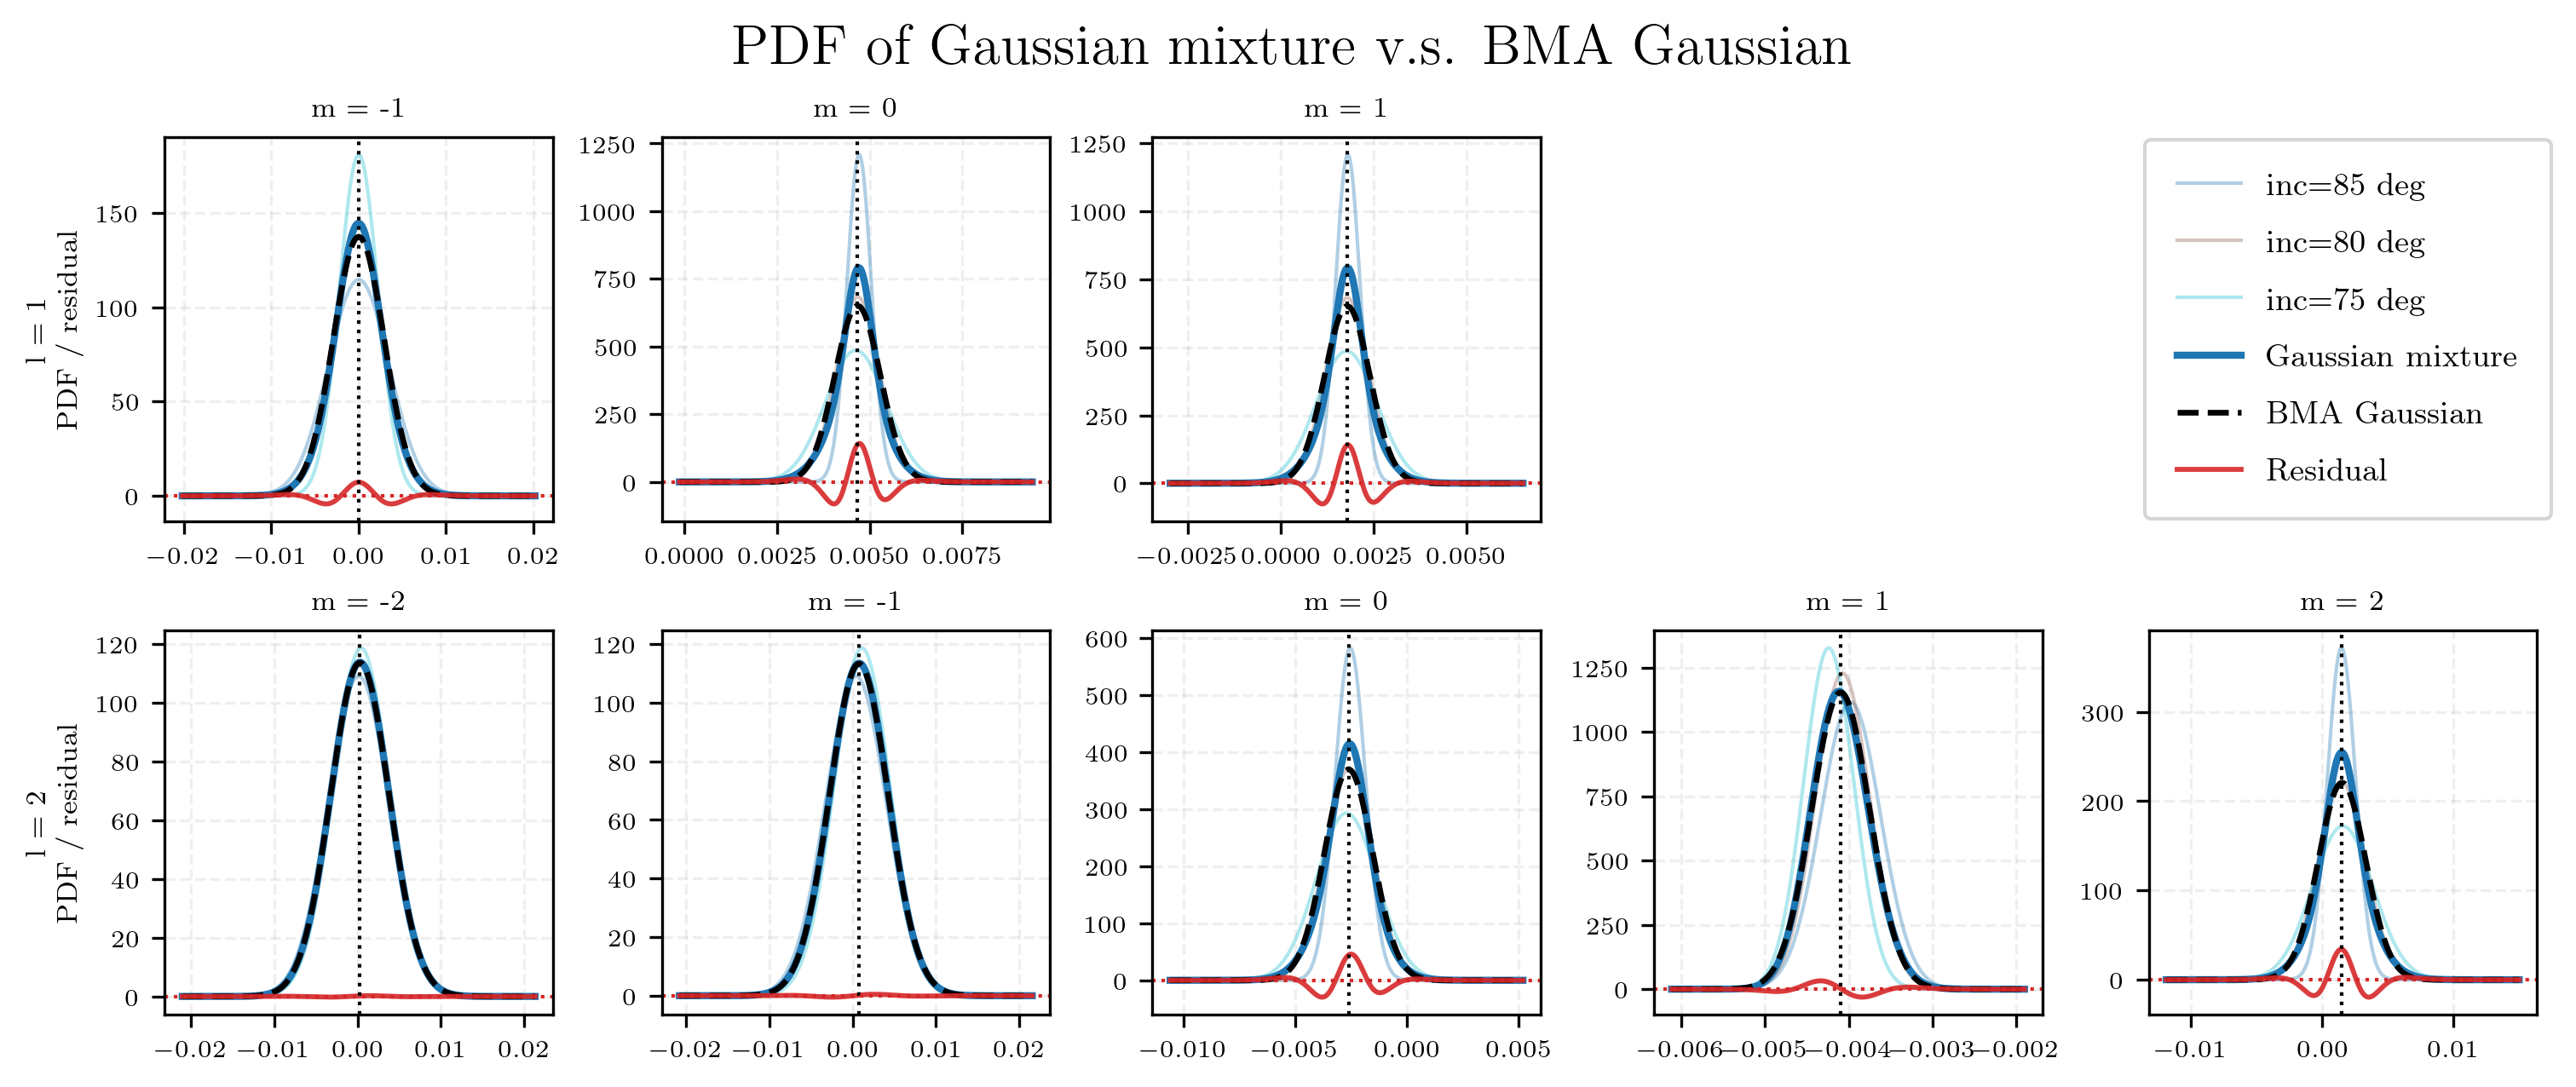

Evidence weights by inclination:
  inc=85 deg: 0.333
  inc=80 deg: 0.333
  inc=75 deg: 0.333


In [35]:
import numpy as np
import matplotlib.pyplot as plt
from spectralmap.mapping import make_map


def normal_pdf(x, mean, var):
    var = np.maximum(var, 1e-12)
    return np.exp(-0.5 * (x - mean) ** 2 / var) / np.sqrt(2.0 * np.pi * var)


def coeff_to_lm(coeff_idx):
    l = int(np.floor(np.sqrt(coeff_idx)))
    m = int(coeff_idx - l * (l + 1))
    return l, m


inclinations = [85, 80, 75]
mus = []
covs = []
log_evs = []


for inc in inclinations:
    map_obj = make_map(mode="rotational", ydeg=4, inc=inc, u=[0.3, 0])
    mu, cov, log_ev = map_obj.solve_posterior(
        y=np.nanmean(flux, axis=0),
        sigma_y=np.nanmean(flux_err, axis=0)/len(wl)**0.5,
        theta=theta,
    )
    mus.append(mu)
    covs.append(cov)
    log_evs.append(log_ev)

log_evs = np.asarray(log_evs, dtype=float)
weights = np.ones_like(log_evs)
weights /= np.sum(weights)

n_coeff_common = min(m.shape[0] for m in mus)
# ydeg = coeff_to_lm(n_coeff_common - 1)[0]
ydeg = 2

# Keep all m values, but anchor the triangle on the left.
# The blank space on the right is reserved for the legend.
n_rows = ydeg
n_cols = 2 * ydeg + 1
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2 * n_cols, 2.07 * n_rows),
    constrained_layout=True,
)
axes = np.atleast_2d(axes)
colors = plt.get_cmap("tab10", len(inclinations))

first_handles = None
first_labels = None

for row_idx, l in enumerate(range(1, ydeg + 1)):
    valid_ms = list(range(-l, l + 1))
    start_col = 0

    for idx, m in enumerate(valid_ms):
        coeff_idx = l * (l + 1) + m
        ax = axes[row_idx, start_col + idx]

        means = np.array([mus[i][coeff_idx] for i in range(len(inclinations))])
        variances = np.array([covs[i][coeff_idx, coeff_idx] for i in range(len(inclinations))])

        bma_mean = np.sum(weights * means)
        bma_var = np.sum(weights * (variances + means**2)) - bma_mean**2
        bma_var = max(float(bma_var), 1e-12)
        bma_std = np.sqrt(bma_var)

        x_min = np.min(means - 5.0 * np.sqrt(np.maximum(variances, 0.0)))
        x_max = np.max(means + 5.0 * np.sqrt(np.maximum(variances, 0.0)))
        x_min = min(x_min, bma_mean - 5.0 * bma_std)
        x_max = max(x_max, bma_mean + 5.0 * bma_std)
        pad = 0.08 * (x_max - x_min if x_max > x_min else 1.0)
        grid = np.linspace(x_min - pad, x_max + pad, 800)

        mixture_pdf = np.zeros_like(grid)
        for i, inc in enumerate(inclinations):
            component_pdf = normal_pdf(grid, means[i], variances[i])
            mixture_pdf += weights[i] * component_pdf
            ax.plot(
                grid,
                component_pdf,
                color=colors(i),
                lw=1.0,
                alpha=0.35,
                label=f"inc={inc} deg" if (row_idx == 0 and idx == 0) else None,
            )

        bma_pdf = normal_pdf(grid, bma_mean, bma_var)
        residual = mixture_pdf - bma_pdf

        ax.plot(grid, mixture_pdf, color="tab:blue", lw=2.0, label="Gaussian mixture" if (row_idx == 0 and idx == 0) else None)
        ax.plot(grid, bma_pdf, color="black", lw=1.6, ls="--", label="BMA Gaussian" if (row_idx == 0 and idx == 0) else None)
        ax.plot(grid, residual, color="tab:red", lw=1.4, alpha=0.9, label="Residual" if (row_idx == 0 and idx == 0) else None)
        ax.axvline(bma_mean, color="black", lw=1.0, ls=":")
        ax.axhline(0.0, color="tab:red", lw=1.0, ls=":")
        ax.set_title(f"m = {m}")
        ax.grid(alpha=0.2)

        if idx == 0:
            ax.set_ylabel(f"l = {l}\nPDF / residual")

        # if row_idx == n_rows - 1:
        #     ax.set_xlabel("Coefficient value")

        if first_handles is None:
            first_handles, first_labels = ax.get_legend_handles_labels()

    # Hide the unused slots on the right so the figure reads as a lower-left triangle.
    for col in range(len(valid_ms), n_cols):
        axes[row_idx, col].axis("off")

# Put the legend in the blank space on the upper-right.
if n_rows > 0:
    legend_anchor_ax = axes[0, -1]
    legend_anchor_ax.axis("off")
    if first_handles:
        legend_anchor_ax.legend(
            first_handles,
            first_labels,
            loc="center left",
            bbox_to_anchor=(-0.05, 0.5),
            frameon=True,
            fontsize=9,
            handlelength=2,
            labelspacing=0.9,
            borderpad=1.0,
        )

fig.suptitle("PDF of Gaussian mixture v.s. BMA Gaussian", fontsize=16)
plt.show()

print("Evidence weights by inclination:")
for inc, w in zip(inclinations, weights):
    print(f"  inc={inc} deg: {w:.3f}")
fig.savefig(PAPER_FIGURES_DIR + "S0136_bma.pdf", dpi=300)

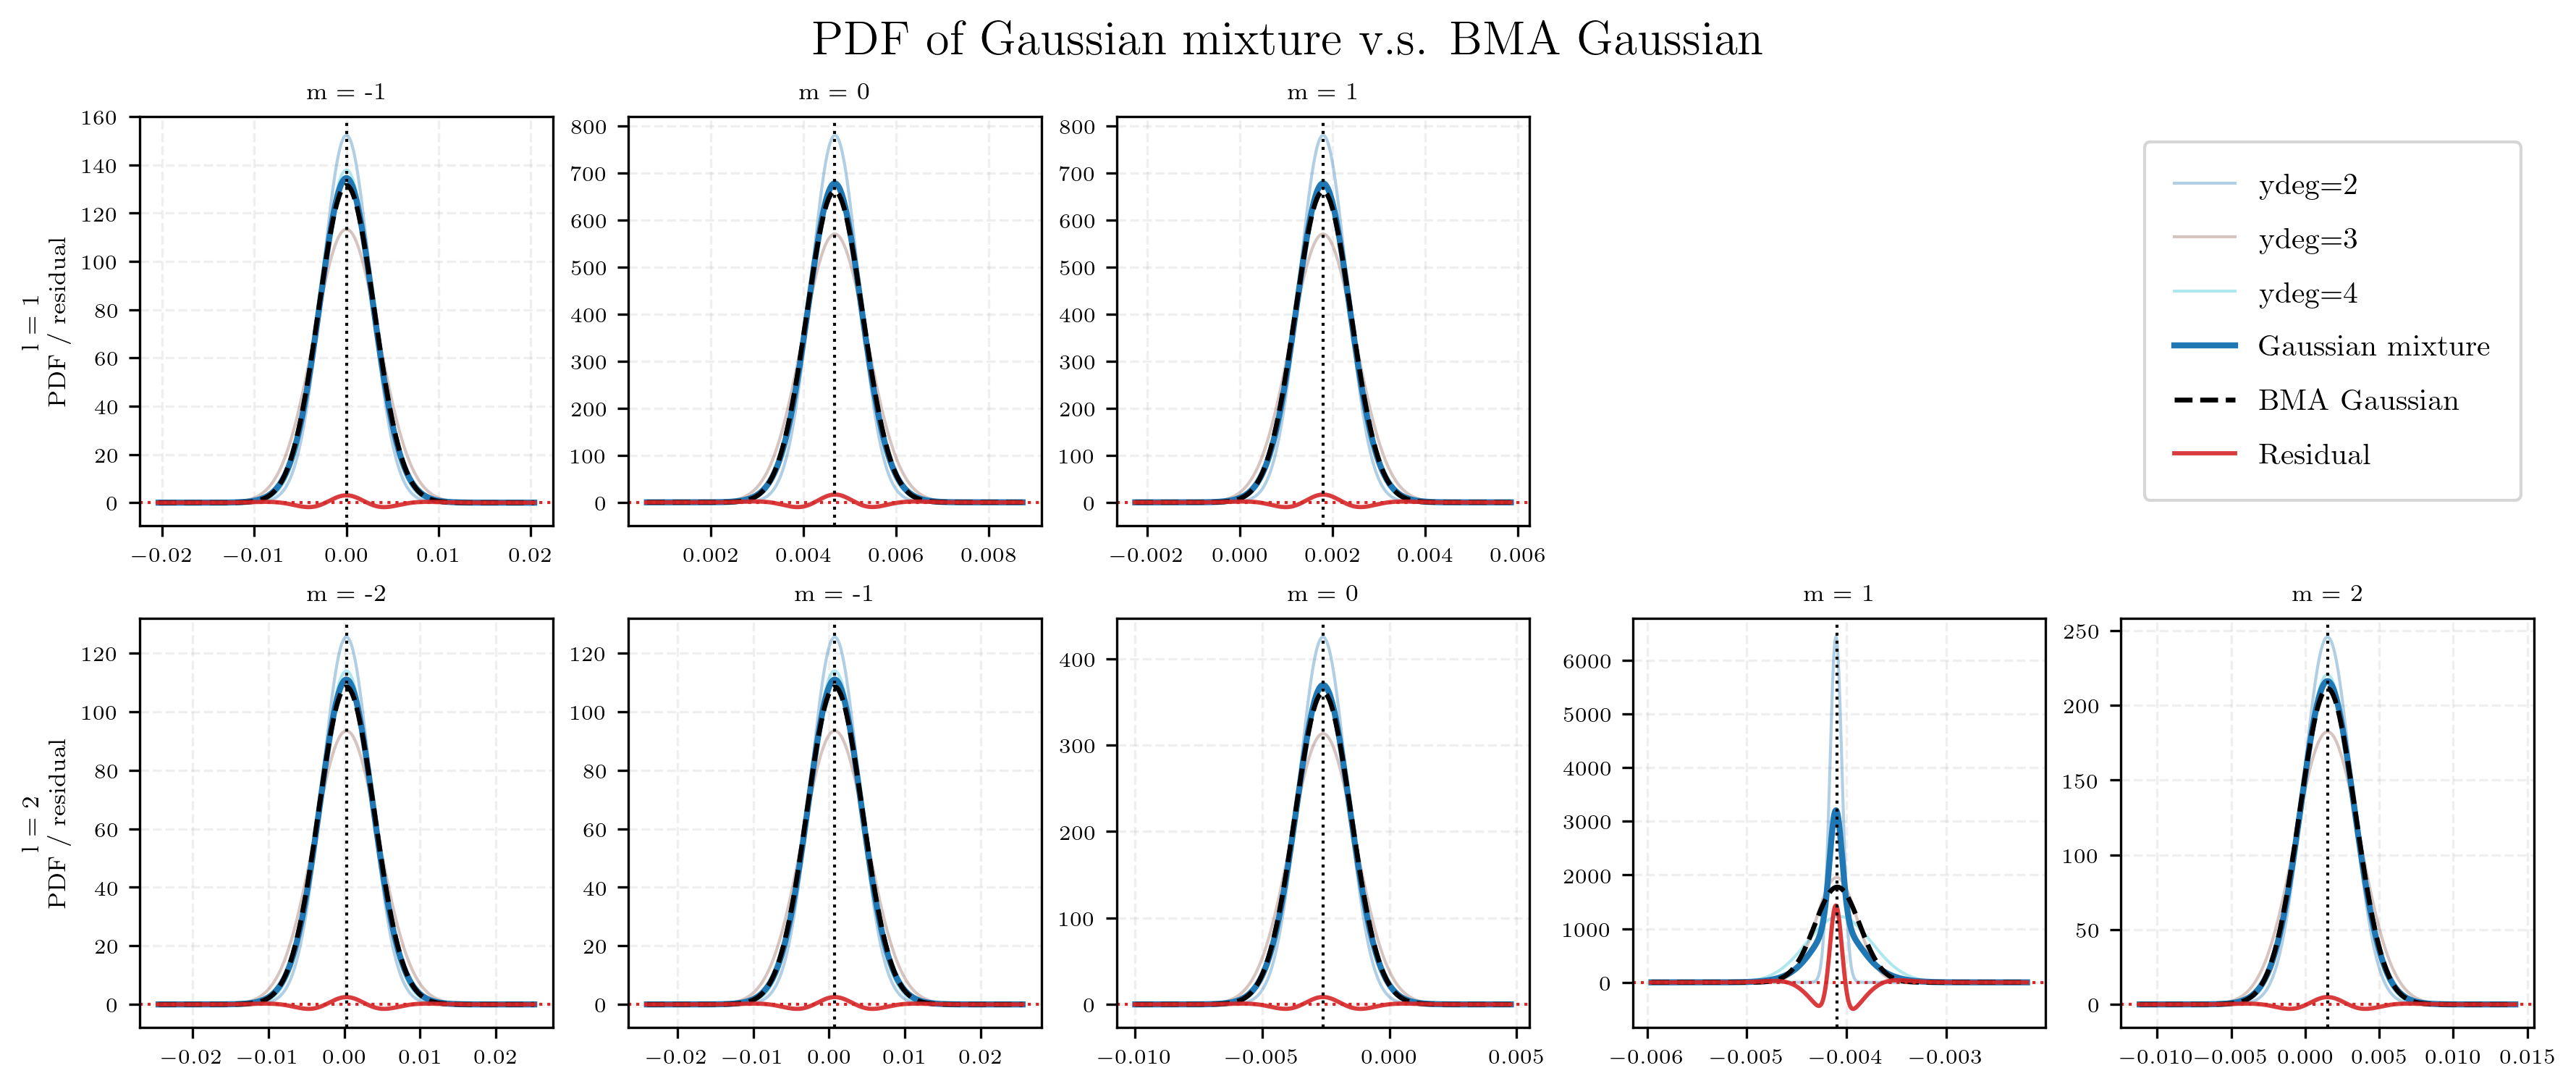

Evidence weights by inclination:
  inc=85 deg: 0.333
  inc=80 deg: 0.333
  inc=75 deg: 0.333


In [36]:
inc = 80
mus = []
covs = []
log_evs = []
ydeg_maxs = range(2, 5)

for ydeg_max in ydeg_maxs:
    map_obj = make_map(mode="rotational", ydeg=ydeg_max, inc=inc, u=[0.3, 0])
    mu, cov, log_ev = map_obj.solve_posterior(
        y=np.nanmean(flux, axis=0),
        sigma_y=np.nanmean(flux_err, axis=0)/len(wl)**0.5,
        theta=theta,
    )
    mus.append(mu)
    covs.append(cov)
    log_evs.append(log_ev)

log_evs = np.asarray(log_evs, dtype=float)
weights = np.ones_like(log_evs)
weights /= np.sum(weights)

n_coeff_common = min(m.shape[0] for m in mus)
# ydeg = coeff_to_lm(n_coeff_common - 1)[0]
ydeg = 2

# Keep all m values, but anchor the triangle on the left.
# The blank space on the right is reserved for the legend.
n_rows = ydeg
n_cols = 2 * ydeg + 1
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(2.35 * n_cols, 2.45 * n_rows),
    constrained_layout=True,
)
axes = np.atleast_2d(axes)
colors = plt.get_cmap("tab10", len(inclinations))

first_handles = None
first_labels = None

for row_idx, l in enumerate(range(1, ydeg + 1)):
    valid_ms = list(range(-l, l + 1))
    start_col = 0

    for idx, m in enumerate(valid_ms):
        coeff_idx = l * (l + 1) + m
        ax = axes[row_idx, start_col + idx]

        means = np.array([mus[i][coeff_idx] for i in range(len(inclinations))])
        variances = np.array([covs[i][coeff_idx, coeff_idx] for i in range(len(inclinations))])

        bma_mean = np.sum(weights * means)
        bma_var = np.sum(weights * (variances + means**2)) - bma_mean**2
        bma_var = max(float(bma_var), 1e-12)
        bma_std = np.sqrt(bma_var)

        x_min = np.min(means - 5.0 * np.sqrt(np.maximum(variances, 0.0)))
        x_max = np.max(means + 5.0 * np.sqrt(np.maximum(variances, 0.0)))
        x_min = min(x_min, bma_mean - 5.0 * bma_std)
        x_max = max(x_max, bma_mean + 5.0 * bma_std)
        pad = 0.08 * (x_max - x_min if x_max > x_min else 1.0)
        grid = np.linspace(x_min - pad, x_max + pad, 800)

        mixture_pdf = np.zeros_like(grid)
        for i, ydeg_max in enumerate(ydeg_maxs):
            component_pdf = normal_pdf(grid, means[i], variances[i])
            mixture_pdf += weights[i] * component_pdf
            ax.plot(
                grid,
                component_pdf,
                color=colors(i),
                lw=1.0,
                alpha=0.35,
                label=f"ydeg={ydeg_max}" if (row_idx == 0 and idx == 0) else None,
            )

        bma_pdf = normal_pdf(grid, bma_mean, bma_var)
        residual = mixture_pdf - bma_pdf

        ax.plot(grid, mixture_pdf, color="tab:blue", lw=2.0, label="Gaussian mixture" if (row_idx == 0 and idx == 0) else None)
        ax.plot(grid, bma_pdf, color="black", lw=1.6, ls="--", label="BMA Gaussian" if (row_idx == 0 and idx == 0) else None)
        ax.plot(grid, residual, color="tab:red", lw=1.4, alpha=0.9, label="Residual" if (row_idx == 0 and idx == 0) else None)
        ax.axvline(bma_mean, color="black", lw=1.0, ls=":")
        ax.axhline(0.0, color="tab:red", lw=1.0, ls=":")
        ax.set_title(f"m = {m}")
        ax.grid(alpha=0.2)

        if idx == 0:
            ax.set_ylabel(f"l = {l}\nPDF / residual")

        # if row_idx == n_rows - 1:
        #     ax.set_xlabel("Coefficient value")

        if first_handles is None:
            first_handles, first_labels = ax.get_legend_handles_labels()

    # Hide the unused slots on the right so the figure reads as a lower-left triangle.
    for col in range(len(valid_ms), n_cols):
        axes[row_idx, col].axis("off")

# Put the legend in the blank space on the upper-right.
if n_rows > 0:
    legend_anchor_ax = axes[0, -1]
    legend_anchor_ax.axis("off")
    if first_handles:
        legend_anchor_ax.legend(
            first_handles,
            first_labels,
            loc="center left",
            bbox_to_anchor=(0.02, 0.5),
            frameon=True,
            fontsize=10,
            handlelength=2,
            labelspacing=0.9,
            borderpad=1.0,
        )

fig.suptitle("PDF of Gaussian mixture v.s. BMA Gaussian", fontsize=16)
plt.show()

print("Evidence weights by inclination:")
for inc, w in zip(inclinations, weights):
    print(f"  inc={inc} deg: {w:.3f}")
# fig.savefig(PAPER_FIGURES_DIR + "SIMP0136_bma.pdf", dpi=600)

### Find Optimal Map Complexity
We now solve for the maps. Since we don't know the complexity of the surface beforehand, we test spherical harmonic degrees ranging from `ydeg=2` to `ydeg=10`. The algorithm will automatically select the degree that best fits the data without overfitting (using the Bayesian Information Criterion).

In [53]:
time_series = np.sort(flux_raw.T, axis=0)

In [ ]:
# Compare two inversion choices: limb darkening vs no limb darkneing

from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from spectralmap.mapping import make_maps
from spectralmap.cluster import find_clusters
from spectralmap.plotting import plot_mollweide_labels, get_cmap

# --- Load quadratic limb-darkening coefficients (robust filename handling) ---
ld_candidates = [
    Path("data/S0136_quadratic_limb_darkening_coeffs.csv"),
    Path("data/quadratic_limb_darkening_coeffs.csv"),
]

ld_path = None
for p in ld_candidates:
    if p.exists():
        ld_path = p
        break

if ld_path is None:
    raise FileNotFoundError(
        "Could not find limb-darkening CSV. Tried: " + ", ".join(str(p) for p in ld_candidates)
    )

ld = np.genfromtxt(
    str(ld_path),
    delimiter=",",
    names=True,
    dtype=None,
    encoding=None,
    invalid_raise=False,
    autostrip=True,
    comments="#",
)

ld_wl = np.asarray(ld["wavelength_um"], dtype=float)
u1 = np.asarray(ld["u1"], dtype=float)
u2 = np.asarray(ld["u2"], dtype=float)

# Ensure monotonic wavelength axis before interpolation
order = np.argsort(ld_wl)
ld_wl = ld_wl[order]
u1 = u1[order]
u2 = u2[order]

# Interpolate u1, u2 onto the data wavelength grid
u1_wl = np.interp(wl, ld_wl, u1)
u2_wl = np.interp(wl, ld_wl, u2)
u_wl = np.column_stack([u1_wl, u2_wl])  # shape = (n_wavelengths, 2)


def run_case(u_value, case_name):
    if u_value is None:
        maps_case = make_maps(
            mode='rotational',
            map_res=30,
            ydegs=np.arange(2, 7),
            verbose=False,
            inc=80,
            projection="moll",
        )
    else:
        maps_case = make_maps(
            mode='rotational',
            map_res=30,
            ydegs=np.arange(2, 7),
            udeg=2,
            u=u_value,
            verbose=False,
            inc=80,
            projection="moll",
        )

    w_all_case, I_all_case, I_cov_all_case = maps_case.marginalized_maps(data)
    F_all_case = I_all_case * amplitudes[:, None] * np.pi
    F_cov_all_case = I_cov_all_case * (np.pi * amplitudes[:, None, None]) ** 2
    F_var_all_case = np.diagonal(F_cov_all_case, axis1=1, axis2=2)

    # Suppress internal diagnostic plots produced by find_clusters,
    # so this cell only shows the requested comparison figures.
    figs_before = set(plt.get_fignums())
    F_regionals_case, F_regional_errs_case, labels_case = find_clusters(
        F_all_case,
        F_cov_all_case,
        n_neighbors=100,
        n_corners=2,
    )
    figs_after = set(plt.get_fignums())
    for fig_num in sorted(figs_after - figs_before):
        plt.close(fig_num)

    return {
        "name": case_name,
        "maps": maps_case,
        "w_all": w_all_case,
        "I_all": I_all_case,
        "I_cov_all": I_cov_all_case,
        "F_all": F_all_case,
        "F_cov_all": F_cov_all_case,
        "F_var_all": F_var_all_case,
        "F_regionals": F_regionals_case,
        "F_regional_errs": F_regional_errs_case,
        "labels": labels_case,
    }


case_limb_darkening = run_case(u_wl, "limb darkening")
case_no_limb_darkneing = run_case(None, "no limb darkneing")

# Expose variables for downstream cells if needed
maps_u_wl = case_limb_darkening["maps"]
maps_u_none = case_no_limb_darkneing["maps"]
F_all_wl_u_wl = case_limb_darkening["F_all"]
F_all_wl_u_none = case_no_limb_darkneing["F_all"]
F_cov_all_wl_u_wl = case_limb_darkening["F_cov_all"]
F_cov_all_wl_u_none = case_no_limb_darkneing["F_cov_all"]
F_regionals_u_wl = case_limb_darkening["F_regionals"]
F_regionals_u_none = case_no_limb_darkneing["F_regionals"]
F_regional_errs_u_wl = case_limb_darkening["F_regional_errs"]
F_regional_errs_u_none = case_no_limb_darkneing["F_regional_errs"]
labels_u_wl = case_limb_darkening["labels"]
labels_u_none = case_no_limb_darkneing["labels"]

print(f"limb darkening:     N regions (including background) = {len(F_regionals_u_wl)}")
print(f"no limb darkneing:  N regions (including background) = {len(F_regionals_u_none)}")

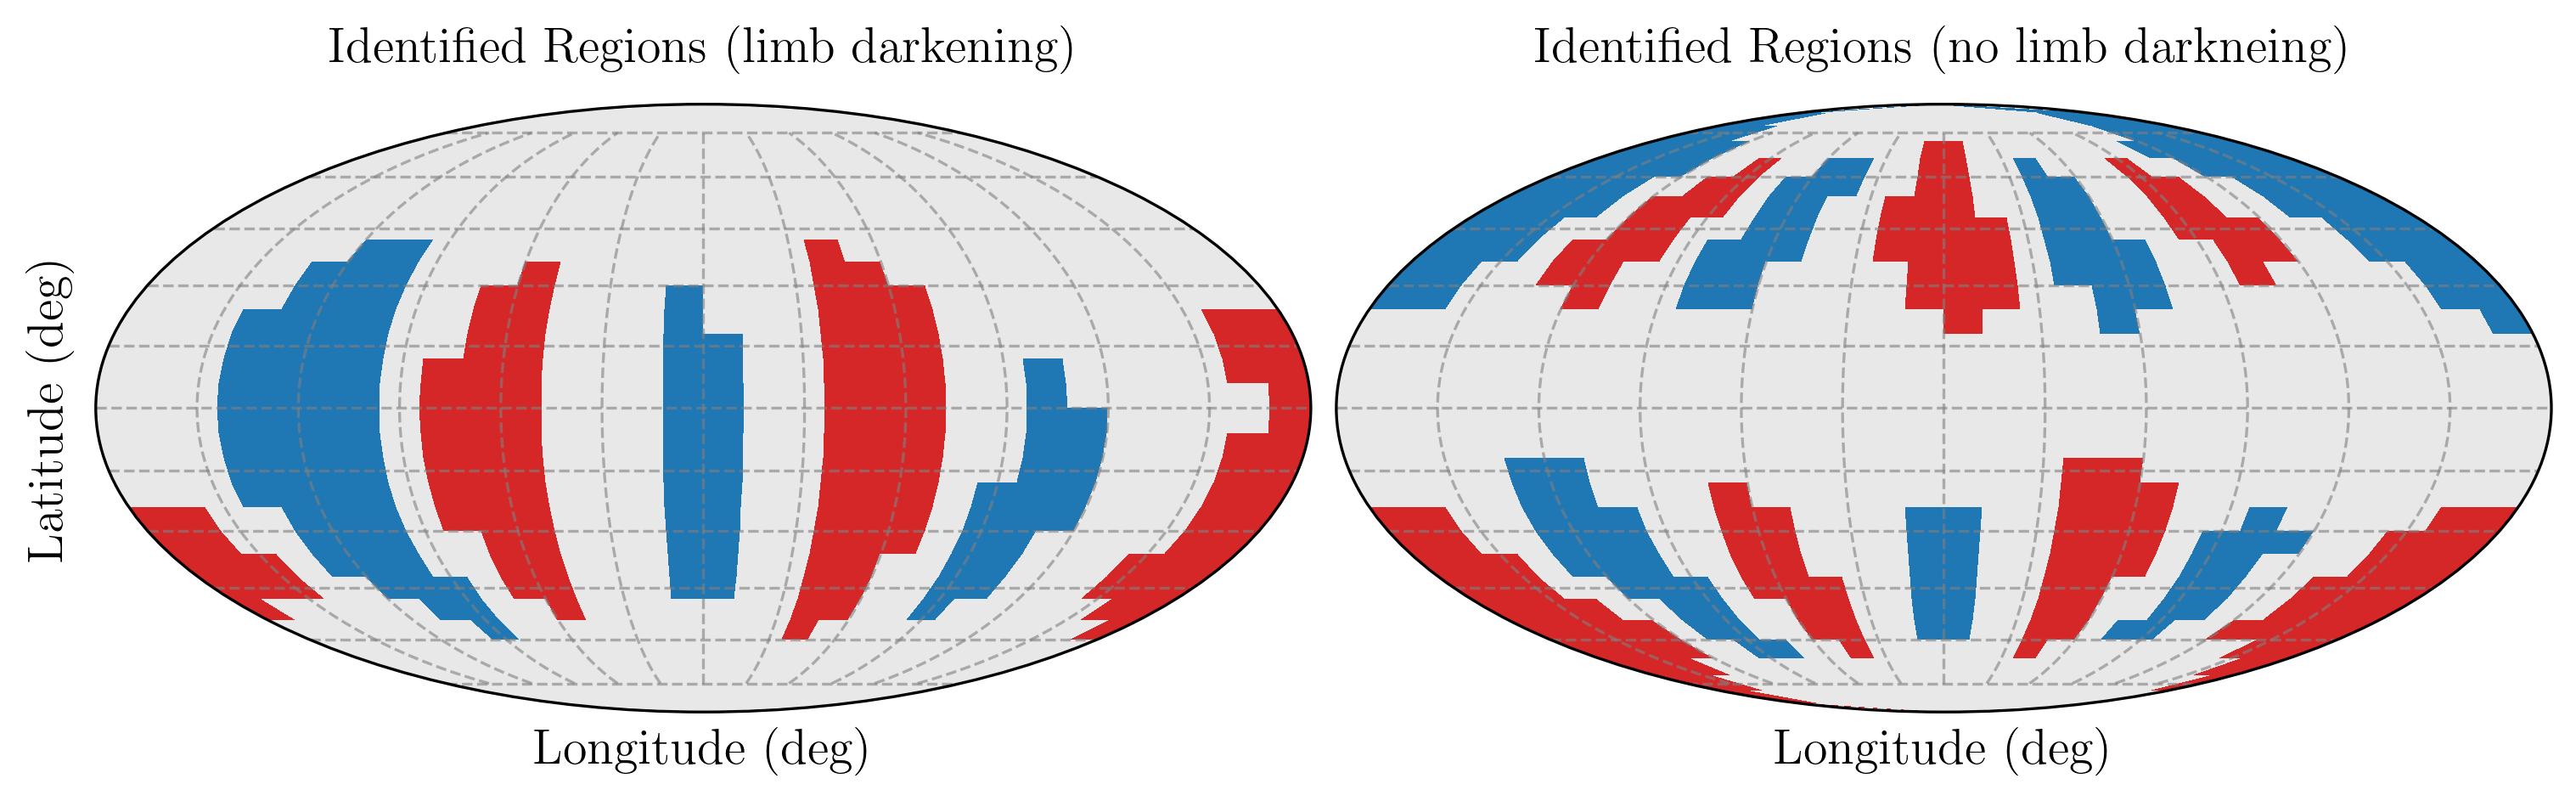

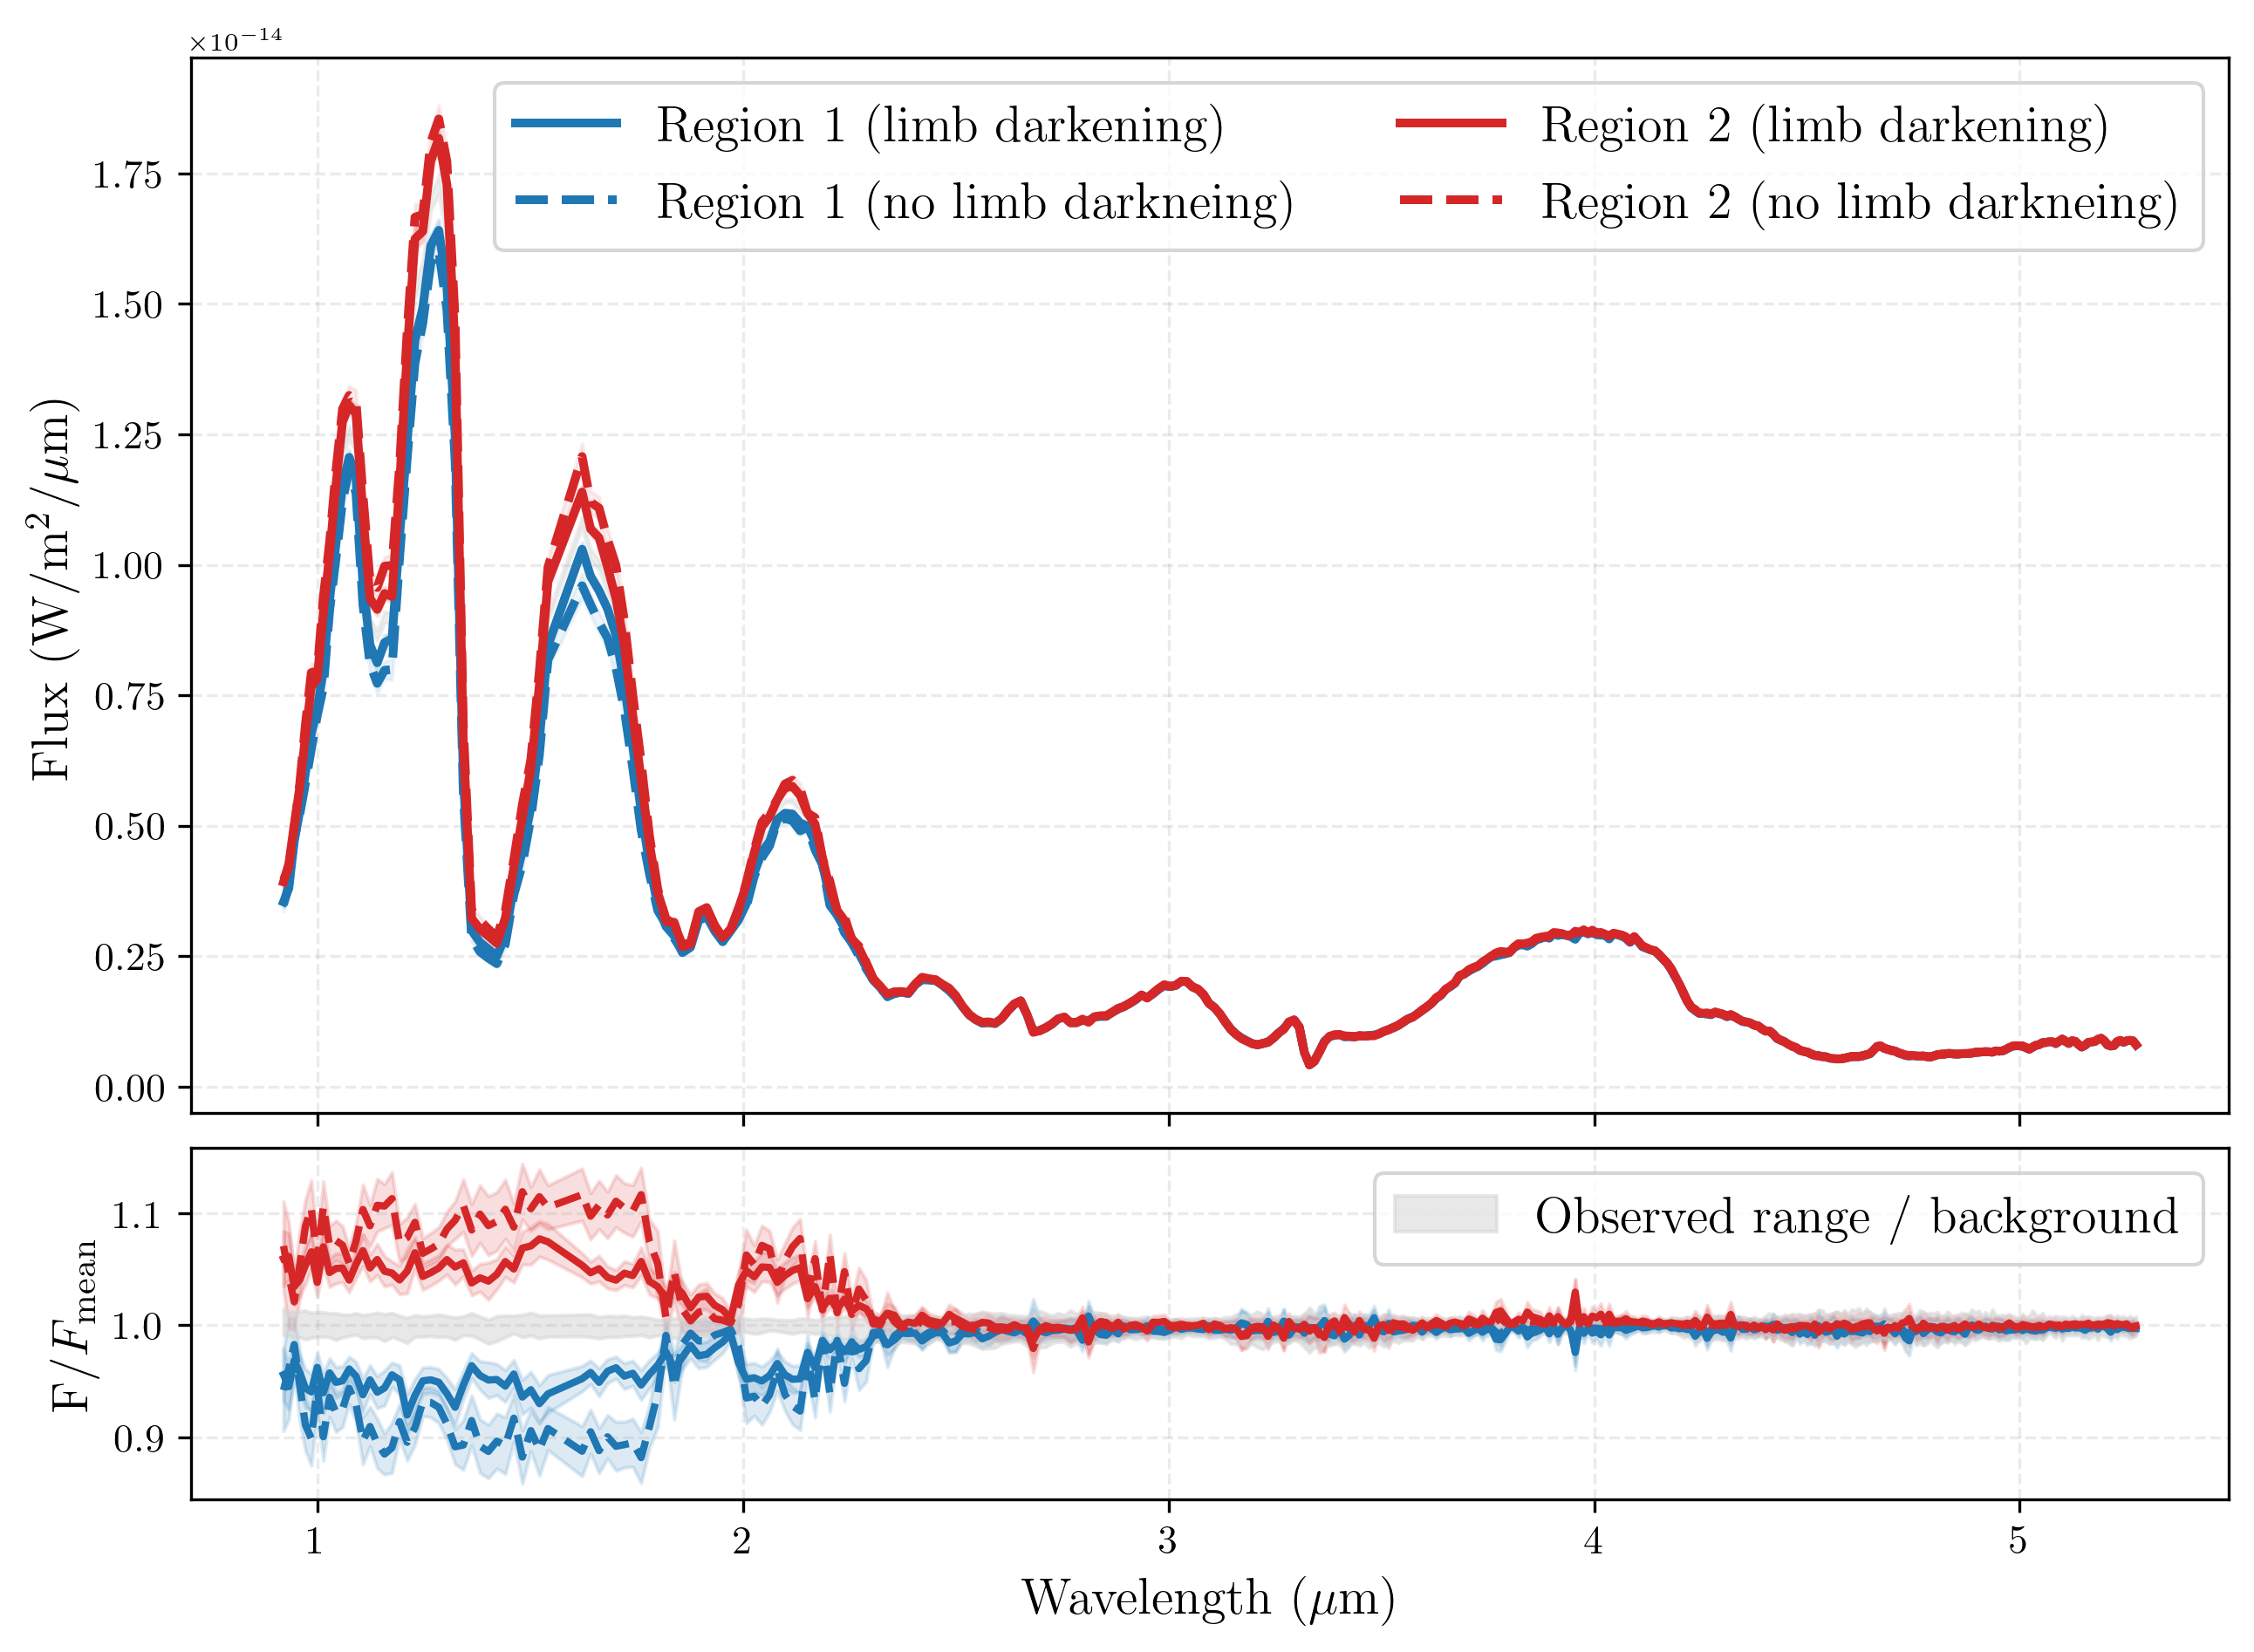

In [63]:
# --- Side-by-side identified-region maps ---
fig, axes = plt.subplots(
    1,
    2,
    figsize=(10, 3.8),
    subplot_kw={"projection": "mollweide"},
    constrained_layout=True,
)

for ax, case in zip(axes, [case_limb_darkening, case_no_limb_darkneing]):
    n_case = len(case["F_regionals"])
    cluster_names = ["Background"] + [f"Region {i+1}" for i in range(n_case - 1)]
    cmap_case = get_cmap(n_case)

    plot_mollweide_labels(
        labels_masked=case["labels"],
        moll_mask=case["maps"].moll_mask,
        map_res=case["maps"].map_res,
        cmap=cmap_case,
        names=cluster_names,
        ax=ax,
        add_colorbar=False,
    )
    ax.set_title(f"Identified Regions ({case['name']})", pad=12, fontsize=M_TITLE_FONTSIZE)
    ax.set_xlabel("Longitude (deg)", fontsize=AXIS_LABEL_FONTSIZE)
    ax.tick_params(axis="both", labelsize=TICK_FONTSIZE)

axes[0].set_ylabel("Latitude (deg)", fontsize=AXIS_LABEL_FONTSIZE)
axes[1].set_ylabel("")
axes[1].set_yticklabels([])
plt.savefig(PAPER_FIGURES_DIR + "S0136_limb_darkening_comparison_maps.pdf", dpi=300)

# --- Overplot recovered 2 regional spectra and residuals ---
# Region index 0 is background; compare regions 1 and 2 if available.
n_nonbg_compare = min(
    2,
    len(case_limb_darkening["F_regionals"]) - 1,
    len(case_no_limb_darkneing["F_regionals"]) - 1,
)

if n_nonbg_compare <= 0:
    raise ValueError("No non-background regions found to compare.")

# Keep region colors consistent between this plot and map labeling style.
n_colors = max(len(case_limb_darkening["F_regionals"]), len(case_no_limb_darkneing["F_regionals"]))
region_cmap = get_cmap(n_colors)

fig, (ax_top, ax_res) = plt.subplots(
    2,
    1,
    figsize=(8.5, 6.2),
    sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
    constrained_layout=True,
)

background = case_no_limb_darkneing["F_regionals"][0]
background_err = case_no_limb_darkneing["F_regional_errs"][0]
for i in range(n_nonbg_compare):
    ridx = i + 1  # skip background
    color = region_cmap(ridx)

    # limb darkening (solid)
    f_ld = case_limb_darkening["F_regionals"][ridx]
    e_ld = case_limb_darkening["F_regional_errs"][ridx]
    ax_top.plot(wl, f_ld, color=color, lw=2.4, ls="-", label=f"Region {ridx} (limb darkening)")
    ax_top.fill_between(wl, f_ld - e_ld, f_ld + e_ld, color=color, alpha=0.15)

    # no limb darkneing (dashed)
    f_nld = case_no_limb_darkneing["F_regionals"][ridx]
    e_nld = case_no_limb_darkneing["F_regional_errs"][ridx]

    ax_top.plot(wl, f_nld, color=color, lw=2.4, ls="--", label=f"Region {ridx} (no limb darkneing)")
    ax_top.fill_between(wl, f_nld - e_nld, f_nld + e_nld, color=color, alpha=0.08)

    # residual panel: limb darkening - no limb darkneing
    ax_res.plot(wl, f_ld / background, color=color, lw=2.0, ls="-")
    ax_res.plot(wl, f_nld / background, color=color, lw=2.0, ls="--")
    ax_res.fill_between(wl, (f_ld - e_ld) / background, (f_ld + e_ld) / background, color=color, alpha=0.15)
    ax_res.fill_between(wl, (f_nld - e_nld) / background, (f_nld + e_nld) / background, color=color, alpha=0.15)

# Add observed time-series range to the first panel as requested
ax_top.fill_between(
    wl,
    time_series[0],
    time_series[-1],
    color="lightgray",
    alpha=0.35,
    zorder=0,
)

ax_top.set_ylabel(r"Flux (W/m$^2$/$\mu$m)", fontsize=AXIS_LABEL_FONTSIZE)
ax_top.grid(alpha=0.25)
ax_top.legend(loc="best", ncol=2, fontsize=LEGEND_FONTSIZE)
ax_top.tick_params(axis="both", labelsize=TICK_FONTSIZE)

# Add gray residual envelope and legend in the second panel
ax_res.fill_between(
    wl,
    time_series[0] / background,
    time_series[-1] / background,
    color="lightgray",
    alpha=0.5,
    label="Observed range / background",
)
ax_res.set_xlabel(r"Wavelength ($\mu$m)", fontsize=AXIS_LABEL_FONTSIZE)
ax_res.set_ylabel(r"F/$F_{\rm{mean}}$", fontsize=AXIS_LABEL_FONTSIZE)
ax_res.grid(alpha=0.25)
ax_res.tick_params(axis="both", labelsize=TICK_FONTSIZE)
ax_res.legend(loc="best", fontsize=LEGEND_FONTSIZE)

plt.savefig(PAPER_FIGURES_DIR + "S0136_limb_darkening_comparison_spectra.pdf", dpi=300)

## 6. Results
Finally, we visualize the identified clusters on the map and plot the mean spectrum for each region.

In [ ]:
# Fp_final = F_regionals[1:] # = np.vstack([X[i_max_1D], X[i_min_1D], X.mean(axis=0)])
# N = len(Fp_final)
# wl_final = np.tile(wl, N)
# noise_final = F_regional_errs[1:]
# Fp_final = Fp_final.reshape(-1)
# noise_final = noise_final.reshape(-1)
# import pandas as pd
# output_df = pd.DataFrame(
#     data=np.array([wl_final, Fp_final, noise_final]).T
# )  # for petitradtrans
# output_df.to_csv(
#     "./NIRSPEC_S0136_2_clusters_08_50.dat", sep=" ", header=False, index=False
# )

# Fp_final = F_regionals[1:] # = np.vstack([X[i_max_1D], X[i_min_1D], X.mean(axis=0)])
# noise_final = F_regional_errs[1:]

# for i in range(N):
#     output_df = pd.DataFrame(
#         data=np.array([wl, Fp_final[i], noise_final[i]]).T
#     )  # for petitradtrans
#     output_df.to_csv(
#         f"./NIRSPEC_S0136_cluster_{i+1}_08_50.dat", sep=" ", header=False, index=False
# )